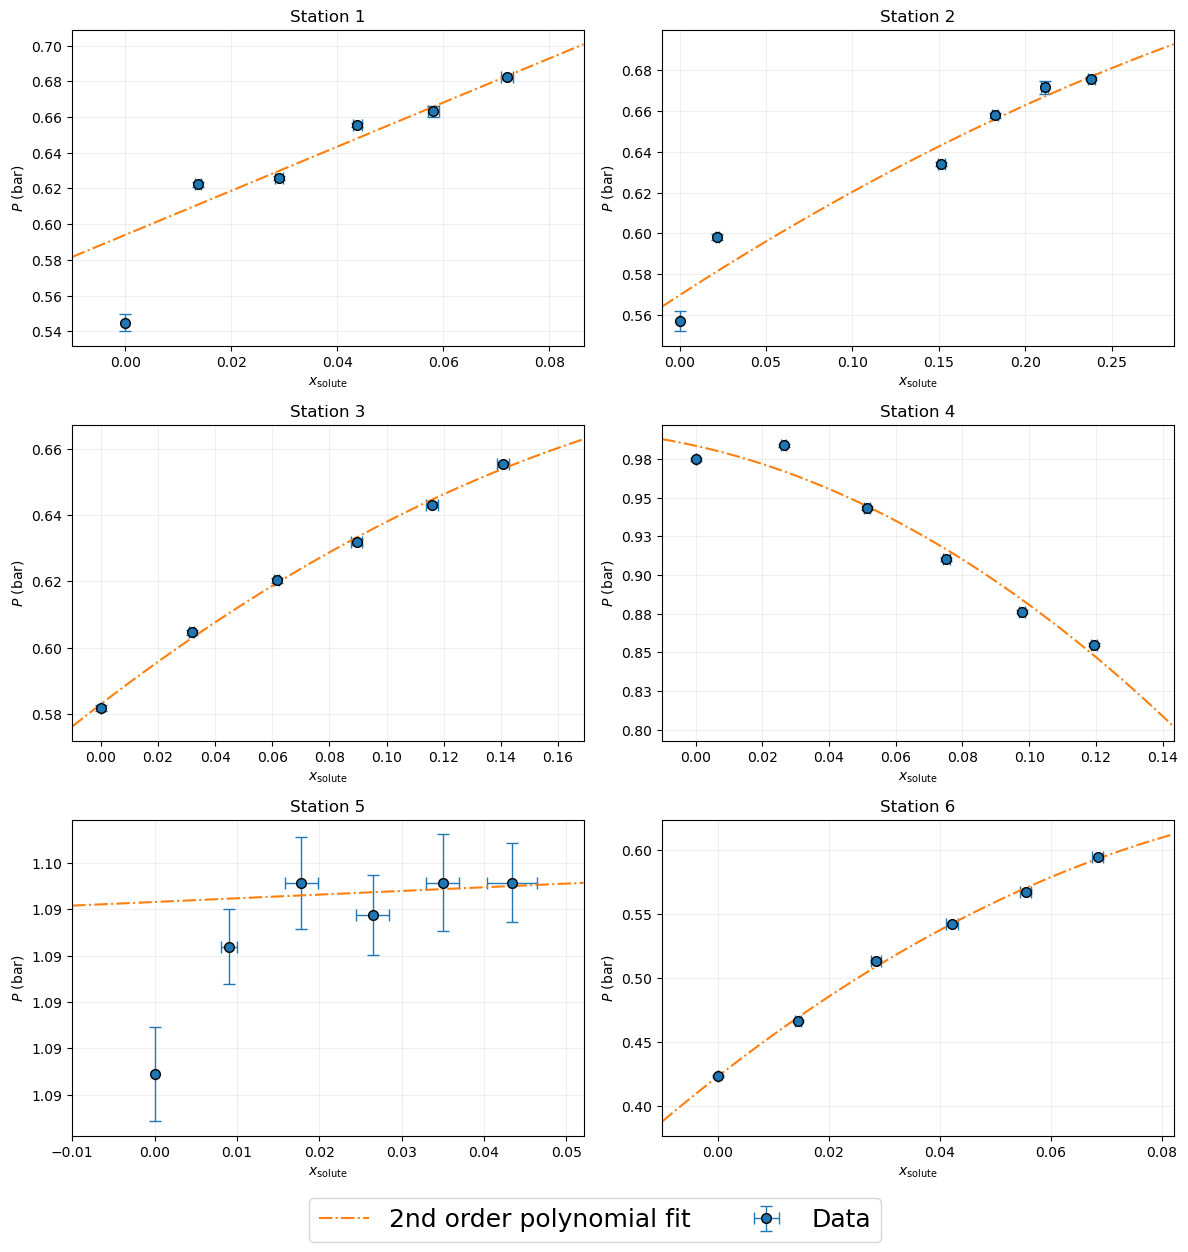

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

stations = [
    {
        "label": "Station 1",
        "x":      [0.00000, 0.01375, 0.02901, 0.04380, 0.05815, 0.07208],
        "x_err":  [0,       0.0005,  0.0007,  0.0009,  0.0010,  0.0011],
        "P":      [7.903,   9.025,   9.076,   9.508,   9.620,   9.894],
        "P_err":  [0.07206, 0.02081, 0.01441, 0.01684, 0.04636, 0.01328],
        "poly":   [0,       17.905,  8.6156334],
    },
    {
        "label": "Station 2",
        "x":      [0.00000, 0.02183, 0.15147, 0.18243, 0.21121, 0.23804],
        "x_err":  [0,       0.001,   0.002,   0.002,   0.002,   0.002],
        "P":      [8.080,   8.677,   9.191,   9.540,   9.738,   9.799],
        "P_err":  [0.07200, 0.02100, 0.01400, 0.01700, 0.04600, 0.01300],
        "poly":   [-5.926010936, 7.918, 8.264676196],
    },
    {
        "label": "Station 3",
        "x":      [0.00000, 0.03173, 0.06151, 0.08952, 0.11590, 0.14079],
        "x_err":  [0,       0.001,   0.001,   0.002,   0.002,   0.002],
        "P":      [8.440,   8.769,   8.997,   9.165,   9.328,   9.503],
        "P_err":  [0.01185, 0.01056, 0.01165, 0.01213, 0.01174, 0.01120],
        "poly":   [-16.17666606, 9.583, 8.455972946],
    },
    {
        "label": "Station 4",
        "x":      [0.00000, 0.02640, 0.05150, 0.07520, 0.09790, 0.11940],
        "x_err":  [0,       0.0007,  0.0009,  0.001,   0.001,   0.001],
        "P":      [14.14,   14.27,   13.68,   13.20,   12.71,   12.40],
        "P_err":  [0.01264, 0.01432, 0.01607, 0.01368, 0.01496, 0.01232],
        "poly":   [-79.82919006, -6.947, 14.26591162],
    },
    {
        "label": "Station 5",
        "x":      [0.00000, 0.00900, 0.01780, 0.02650, 0.03500, 0.04340],
        "x_err":  [0,       0.001,   0.002,   0.002,   0.002,   0.003],
        "P":      [15.83,   15.87,   15.89,   15.88,   15.89,   15.89],
        "P_err":  [0.01479, 0.01164, 0.01436, 0.01251, 0.01519, 0.01231],
        "poly":   [0,       0.115,   15.88396443],
    },
    {
        "label": "Station 6",
        "x":      [0.00000, 0.01447, 0.02854, 0.04220, 0.05549, 0.06841],
        "x_err":  [0,       0.0006,  0.0009,  0.001,   0.001,   0.001],
        "P":      [6.144,   6.767,   7.444,   7.860,   8.233,   8.624],
        "P_err":  [0.01150, 0.01191, 0.01349, 0.01312, 0.01269, 0.01517],
        "poly":   [-190.3137059, 49.064, 6.137139817],
    },
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, s in zip(axes.flat, stations):
    x = np.array(s["x"])
    P = np.array(s["P"])
    x_err = np.array(s["x_err"])
    P_err = np.array(s["P_err"])

    ax.errorbar(x, P/14.5037738 , xerr=x_err, yerr=P_err/14.5037738 ,
                fmt='o', markersize=7, capsize=4, lw=1, label="Data", markeredgecolor='black')

    domain = x.max() - x.min()

    x_fit = np.linspace(-0.01, x.max()+0.2*domain, 3000)
    a2, a1, a0 = s["poly"]
    P_fit = a2 * x_fit**2 + a1 * x_fit + a0
    ax.plot(x_fit, P_fit/14.5037738 , lw=1.5, label="2nd order polynomial fit", ls='dashdot')

    ax.set_title(s["label"])
    ax.set_xlabel("$x_\\mathrm{solute}$")
    ax.set_ylabel("$P$ (bar)")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.grid(alpha=0.2)

    ax.set_xlim(-0.01, x.max()+0.2*domain)
    ax.set_ylim(ax.get_ylim())

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           loc="lower center", bbox_to_anchor=(0.5, -0.05), 
           frameon=True, fontsize=18, ncol=2)
fig.tight_layout(rect=[0, 0, 1, 1])
fig.savefig("stations_Pvsx.pdf", bbox_inches='tight')